In [40]:
import numpy as np
import torch
from torch.autograd import grad
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np

# from pinnutils import *
from scipy.interpolate import griddata
from itertools import product, combinations
from scipy.io import savemat, loadmat
from torch.optim.lr_scheduler import ExponentialLR, MultiStepLR
from tqdm import tqdm_notebook as tqdm 
import torch.nn as nn
import torch.nn.functional as F
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from tqdm import tqdm_notebook as tqdm
from scipy.linalg import sqrtm
from chebyshev_utils import *
from GEOMLOSS import samples_loss

import matplotlib as mpl
import matplotlib.font_manager
fpaths = matplotlib.font_manager.findSystemFonts()
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })
matplotlib.rcParams.update({'font.size': 16})
import seaborn as sns

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Simulate toggle_switch and generate data

In [7]:
def toggle_switch(x,model_params_):
    a1, a2, b1, b2, K1, K2, n = model_params_

    x_ = np.zeros_like(x)
    f = np.zeros_like(x);
    xn = x**n + 0;
    f[:,0] = (a1*(xn[:,0])/(K1**n + xn[:,0])) + b1*(K1**n)/(K1**n + xn[:,1]) # degration is always set to one
    f[:,1] = (a2*(xn[:,1])/(K2**n + xn[:,1])) + b2*(K2**n)/(K2**n + xn[:,0]) # degration is always set to one

    return f

def g_rate(x1,x2,gr):
    """Growth propensity based on gene2 expression."""
    return gr*( ((x2**2) / (1 + x2**2)) + ((x1**2) / (1 + x1**2)) ) #gr*( ((x2**2) / (1 + x2**2)) ) 


def simulate_toggle_with_growth(nsamples, init, Nsnaps, Ndim, seed_, maxiter, model_params, vol, gr, growth_flag=False, reaction_flag=False):
    dt = 0.01; lx = 1
    np.random.seed(seed_)

    xold = init + 0*np.zeros((Ndim, nsamples))  # shape (Ndim, nsamples)
    tt = np.zeros(Nsnaps)
    samples_fullx = []  # will store a list of arrays with shape (n(t), Ndim)

    for snap in range(Nsnaps):
        steps = int(maxiter / Nsnaps)
        t_snap = snap * steps * dt
        tt[snap] = t_snap

        for _ in range(steps):
            if(reaction_flag):
                fval = toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;
            else:
                fval = 0.1*toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + 0.1*lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - 0.1*lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;

            if(growth_flag):
                x1 = xold[0]; x2 = xold[1];
                growth_probs = g_rate(x1, x2, gr) * dt
                divide_flags = np.random.rand(x2.shape[0]) < growth_probs
                new_cells = xold[:, divide_flags]  # shape: (Ndim, #dividing cells)

                if new_cells.shape[1] > 0:
                    xold = np.concatenate([xold, new_cells], axis=1)

        samples_fullx.append(xold.T.copy())

    return samples_fullx, tt

model_params = np.array([1., 3., 1.0, 1.0, 1.0, 2.0, 2.0])

Ndim = 2; vol = 5; nsamples = 401; Nsnaps = 5; seed = 0; maxiter = 201; 

gr = 2; #growth-rate
growth_flag_ = True; # Set True if growth is modeled
reaction_flag_ = True; # Set True if the reaction is modeled 
samples_full, tt = simulate_toggle_with_growth(nsamples,np.zeros((Ndim, nsamples)),Nsnaps,Ndim,seed,maxiter,model_params,vol,gr,\
                                               growth_flag=growth_flag_,reaction_flag=reaction_flag_);
samples_full = samples_full[:] 
nsnaps = len(samples_full); 
tt = tt[:]
dt = tt[1] - tt[0];
print(" physical-times of measurement ", tt, " dt ", dt, " nsnaps ", nsnaps)

 physical-times of measurement  [0.  0.4 0.8 1.2 1.6]  dt  0.4  nsnaps  5


### Tracking total-mass over time

In [8]:
nsamples = samples_full[0].shape[0]; # This is set b
mass_vec = np.ones((nsnaps,))
print(0, len(samples_full[0]))
for k in range(1,nsnaps):
    mass_vec[k] = len(samples_full[k])/len(samples_full[0])
    print(k, len(samples_full[k]))
mass_vec = torch.tensor(mass_vec,dtype=torch.float32,device=device)
print(" ground-truth mass ratio over time ", mass_vec)

0 455
1 659
2 1155
3 2368
4 5078
 ground-truth mass ratio over time  tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], device='cuda:0')


### Visualize mRNA count data

(455, 2)
(659, 2)
(1155, 2)
(2368, 2)
(5078, 2)


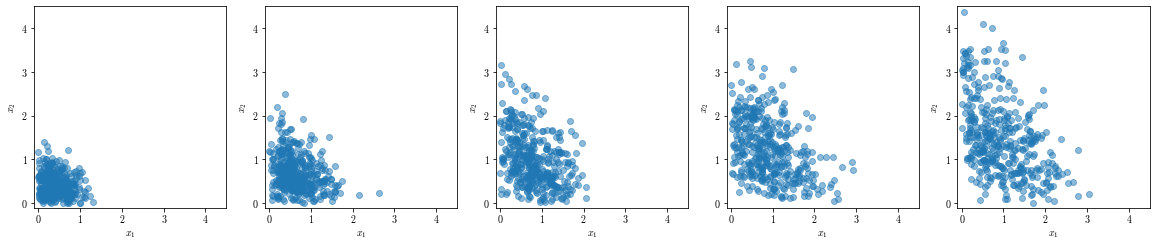

In [9]:
for k in range(0, len(samples_full)):
    plt.subplot(1,len(samples_full),k+1)
    print(samples_full[k].shape)
    ind_s = np.arange(0,samples_full[k].shape[0])
    np.random.shuffle(ind_s)
    plt.scatter(samples_full[k][ind_s[0:400],0],samples_full[k][ind_s[0:400],1],alpha=0.5)
    plt.xlim(-0.1,4.5); plt.ylim(-0.1,4.5)
    plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.gcf().set_size_inches(20,3.7)

## Sample data via MMOT

In [10]:
def samples_rep(samples_):
    nrep = 1;
    print(" # of repetitions ", nrep)

    ### shuffle data to de-correlate the data in time
    Dist_ = np.zeros((len(samples_),nrep,nsamples,Ndim))   
    for k in range(0, len(samples_)):
        print(Dist_.shape)
        ind_s = np.arange(0,samples_[k].shape[0])
        for j in range(0, nrep):
            np.random.shuffle(ind_s)
            Dist_[k,j,:,:] = samples_[k][ind_s[0:nsamples],0:Ndim]

    ### Trajectory sampling
    Dist = np.zeros((len(samples_),nrep*nsamples,Ndim))
    batch_ot_samples  =  torch.tensor(np.zeros((len(samples_),nrep*nsamples,Ndim)),dtype=torch.float32,device=device)
    for j in range(0, nrep):
        before_ot = torch.tensor(Dist_[:,j,:,0:Ndim],dtype=torch.float32)
        Dist[:,j*nsamples:(j+1)*nsamples,:] = Dist_[:,j,:,:]
        before_ot = torch.tensor(Dist[:,j*nsamples:(j+1)*nsamples,:],dtype=torch.float32)
        batch_ot_samples[:,j*nsamples:(j+1)*nsamples,:] = mmot_trajectories(before_ot,nsamples,device); #stitch_ot_trajectories(before_ot).to(device)

    return Dist, batch_ot_samples
        
Dist, batch_ot_samples = samples_rep(samples_full) #batch_ot_samples
tp = tt + 0;
print(tp.shape, Dist.shape, tp)
print(Dist[:,10,-1],tp)

 # of repetitions  1
(5, 1, 455, 2)
(5, 1, 455, 2)
(5, 1, 455, 2)
(5, 1, 455, 2)
(5, 1, 455, 2)
(5,) (5, 455, 2) [0.  0.4 0.8 1.2 1.6]
[0.00665944 0.94790544 1.15338458 1.32071207 2.14455436] [0.  0.4 0.8 1.2 1.6]


## Validate the score-model by generating the data 

In [45]:
def setup_model(Ndim, mean, std, Np, seed_, spectral_flag=True):
    """
    Setup the encoder model and optimizer.
    """
    if(spectral_flag):
        print(" Applying Spectral-Norms ")
        encoder = SpectralNormDNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)
    else:
        print(" Vanilla DNN ")
        encoder = DNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)       
    
    print("#parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))
    return encoder, list(encoder.parameters())

Np = 30; spectral_flag = False; L = 10; n_epochs = 50_01; batch_size_score = nsamples + 0;
X_train, X_data, X_mean, X_std, sigma = generate_noisy_training_data_batch(Dist[:,0:nsamples,:], Ndim, tp, L, nsamples, nsnaps, device);
scoreNet, params = setup_model(Ndim, X_mean, X_std, Np, 0, spectral_flag);
start_time = time.time()
    
scoreNet = DSM_training_batched(Ndim, scoreNet, X_train, X_data, sigma, nsnaps, nsamples, L, adp_flag=1, n_epochs=n_epochs, bs=batch_size_score, device=device);
# print(" time-taken ", time.time() - start_time)
# torch.save(scoreNet, model_path)
# scoreNet = scoreNet.eval()

 done with time  0
 done with time  1
 done with time  2
 done with time  3
 done with time  4
 X_train shape  torch.Size([5, 10, 455, 4])
 X_data shape  torch.Size([5, 455, 2])
 X-mean shape  torch.Size([1, 4])  X-std shape  torch.Size([1, 4])
 Vanilla DNN 
#parameters: 3932
cuda
 number of batches  1
 Xtrain device  cuda:0  Xdata device  cuda:0


  0%|          | 0/5001 [00:00<?, ?it/s]

epoch: 0 c_: tensor([0.1973, 0.1985, 0.1985, 0.1982, 0.2075], device='cuda:0')
epoch: 250 c_: tensor([0.1027, 0.2242, 0.2135, 0.3538, 0.1058], device='cuda:0')
epoch: 500 c_: tensor([0.1204, 0.2604, 0.1634, 0.3792, 0.0766], device='cuda:0')
epoch: 750 c_: tensor([0.1106, 0.2249, 0.1312, 0.4724, 0.0609], device='cuda:0')
epoch: 1000 c_: tensor([0.0933, 0.2382, 0.1096, 0.5066, 0.0523], device='cuda:0')
epoch: 1250 c_: tensor([0.0805, 0.2780, 0.0958, 0.4975, 0.0481], device='cuda:0')
epoch: 1500 c_: tensor([0.0734, 0.3268, 0.0855, 0.4687, 0.0455], device='cuda:0')
epoch: 1750 c_: tensor([0.0739, 0.3813, 0.0810, 0.4174, 0.0463], device='cuda:0')
epoch: 2000 c_: tensor([0.0863, 0.3967, 0.0844, 0.3800, 0.0525], device='cuda:0')
epoch: 2250 c_: tensor([0.1202, 0.3151, 0.0978, 0.4012, 0.0657], device='cuda:0')
epoch: 2500 c_: tensor([0.1689, 0.2004, 0.1175, 0.4267, 0.0864], device='cuda:0')
epoch: 2750 c_: tensor([0.1751, 0.1884, 0.1196, 0.4279, 0.0890], device='cuda:0')
epoch: 3000 c_: tensor

## Validate the score-model by generating the data

In [47]:
scoreNet = scoreNet.eval()

def validate_score(scoreNet,Ndim,nsnaps,Dist,L):
    nsamples = Dist.shape[1];
    loss = samples_loss.SamplesLoss("energy")
    eps = 5e-3; maxiter = 100; total_divergence = 0;
    for tinf in range(0,nsnaps):
        with torch.no_grad():
            infNet = scoreNet.eval()
            init_  = np.random.uniform(1.0,4.0,(nsamples,Ndim+2))  #
            init_[:,0:Ndim] = Dist[tinf,:,0:Ndim]
            print(" true mean ",np.mean(Dist[tinf,:,0:Ndim],axis=0)[0:Ndim])
            sol = generate_data_DSM(eps,maxiter,infNet,nsamples,init_,tp[tinf],L);
            divergence = loss(torch.tensor(sol[:,0:Ndim],dtype=torch.float32,device=device),torch.tensor(Dist[tinf,:,0:Ndim],dtype=torch.float32,device=device))
            print(" divergence for tinf ", tinf, " is ", divergence)
            total_divergence = divergence + total_divergence
            print(" \n ")
    print(" total-divergence ", total_divergence)
    return scoreNet

def generate_data_DSM(eps,maxiter,infNet,Nsamples,init_,time_,L):
    eps = 1e-4;
    sol = torch.tensor(init_,dtype=torch.float32).to(device)
    sol[:,Ndim+1] = time_
    sigma = geometric_sequence(L);
    for k in range(0,L):
        alpha = eps*((sigma[k]**2)/(sigma[L-1]**2))
        sol[:,Ndim] = sigma[k]
        for t in range(0,500):
            z = torch.normal(0, 1, size=(Nsamples, Ndim)).to(device)
            guru = infNet(sol) 
            sol[:,0:Ndim] = sol[:,0:Ndim] + 0.5*alpha*guru + np.sqrt(alpha)*z
    print(" final mean ",torch.mean(sol,axis=0)[0:Ndim])       
    sol = sol.cpu().data.numpy().reshape(Nsamples,Ndim+2)
    return sol

_ = validate_score(scoreNet,Ndim,nsnaps,Dist[:,:,0:Ndim],L);

 true mean  [0.41626041 0.42702313]
 final mean  tensor([0.4928, 0.4172], device='cuda:0')
 divergence for tinf  0  is  tensor(0.0100, device='cuda:0')
 
 
 true mean  [0.67697472 0.68229247]
 final mean  tensor([0.6331, 0.6558], device='cuda:0')
 divergence for tinf  1  is  tensor(0.0041, device='cuda:0')
 
 
 true mean  [0.84843116 0.99201251]
 final mean  tensor([0.8443, 0.8732], device='cuda:0')
 divergence for tinf  2  is  tensor(0.0109, device='cuda:0')
 
 
 true mean  [0.92200411 1.2591351 ]
 final mean  tensor([0.9126, 1.1864], device='cuda:0')
 divergence for tinf  3  is  tensor(0.0091, device='cuda:0')
 
 
 true mean  [0.95039213 1.47068091]
 final mean  tensor([1.0125, 1.4543], device='cuda:0')
 divergence for tinf  4  is  tensor(0.0053, device='cuda:0')
 
 
 total-divergence  tensor(0.0394, device='cuda:0')


In [50]:
def compute_conditional_distributions_chebyshev_with_growth(Dist, batch_size, mass_, nodes_fit, nodes_eval, reg_, sigma, err_flag=False,device='cuda'):
    """
    Compute conditional distributions using Chebyshev polynomial interpolation.

    Parameters:
    - Dist: Tensor of shape [T, nsamples, Ndim], time × samples × dimensions
    - batch_size: Number of trajectories to sample
    - nodes_fit: Tensor of shape [B, T1], time points for fitting (can vary per batch)
    - nodes_eval: Tensor of shape [B, T2], time points for evaluation (can vary per batch)
    - reg_: Regularization strength for Chebyshev interpolation
    - sigma: Standard deviation of Gaussian noise to add to inputs
    - ot: (Optional) flag for using optimal transport logic (unused here)

    Returns:
    - Xtrain: [batch_size * T2, Ndim + 2], inputs for training with noise and time appended
    - ytrain: [batch_size * T2, Ndim], interpolated derivatives
    - err: Relative interpolation error
    """

    nsamples = Dist.shape[1]
    Np = nodes_eval.shape[1]
    Ndim = Dist.shape[2]
    err = 0;

    # Initialize output tensors
    Xtrain = torch.zeros((batch_size * Np, Ndim + 2), dtype=torch.float32, device=device)
    ytrain = torch.zeros((batch_size * Np, Ndim), dtype=torch.float32, device=device)
    #mass_weight = torch.zeros((batch_size * Np), dtype=torch.float32, device=device)

    # Select batch of trajectories at random
    xind = torch.randint(0, nsamples, (batch_size,))
    Dist = torch.tensor(Dist, dtype=torch.float32, device=device)

    mass_weight = torch.permute(mass_[:,xind],(1,0))

    # Permute and extract [B, T, Ndim]
    x = torch.permute(Dist[:, xind, 0:Ndim], (1, 0, 2))

    # Fit Chebyshev polynomial interpolants
    coeffs, P, P_prime, (a, b) = batched_chebyshev_interpolate(
        nodes_fit, x, degree = nodes_fit.shape[1] - 1, lambda_reg=reg_, penalty='curvature'
    ) # always fitting polynomial of degree n-1.

    # Evaluate polynomial and derivative
    x_interp = P(nodes_eval)        # [B, T2, Ndim]
    dx_interp = P_prime(nodes_eval) # [B, T2, Ndim]

    # Compute interpolation error (relative MSE)
    if(err_flag):
        err = torch.mean((x_interp - x) ** 2) / torch.mean(x ** 2)

    # Construct training set
    Xtrain[:, Ndim] = 0.01
    Xtrain[:, Ndim + 1] = nodes_eval.view(batch_size * Np)

    mut = x_interp.view(batch_size * Np, Ndim)
    Xtrain[:, 0:Ndim] = mut + sigma * torch.randn_like(mut)
    ytrain[:, 0:Ndim] = dx_interp.view(batch_size * Np, Ndim)
    
    return Xtrain, ytrain, mass_weight

In [62]:
fac = 2;
uniform_kind = torch.tensor(np.linspace(tp[0],tp[-1],fac*tp.shape[0]))
print(" data nodes ", tp)

data_nodes = torch.tensor(tp,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
uniform_nodes = torch.tensor(uniform_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)

batch_ot_samples_uniform = interpolate_old2new(batch_ot_samples, data_nodes, uniform_nodes).to(device);

batch_size = nsamples + 0; # #batch_ot_samples.shape[1] #*nsamples;
uniform_batch = uniform_kind.expand(batch_size,-1).to(device)

print(" shape of nodes ",  uniform_batch.shape, batch_ot_samples_uniform.shape)

 data nodes  [0.  0.4 0.8 1.2 1.6]
 shape of nodes  torch.Size([455, 10]) torch.Size([10, 455, 2])


### Estimating regularization strength for chebyshev interpolants

In [64]:
data_full = torch.tensor(tp,dtype=torch.float32).expand(batch_ot_samples.shape[1],-1).to(device)
data_highres = uniform_kind.expand(batch_ot_samples.shape[1],-1).to(device)
best_lam,_,_,_ = select_best_lambda(batch_ot_samples, batch_ot_samples.shape[1], data_full, data_full, Ndim, device);
print(" best_lam ", best_lam)

[λ-selection] Initial error: 0.5359
[λ-selection] Best λ (≥80% drop): 0.0010
[λ-selection] Test errors: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[λ-selection] Vel magnitudes: [0.53585172 0.53539234 0.47882175 0.45147246 0.41519064 0.38797605
 0.39255324 0.36205587 0.31369302 0.32918993 0.28092873 0.25448322
 0.21632215 0.19764738]
 best_lam  0.001


## Flow-matching with growth

In [69]:
def div_neural(drift,inp_,Ndim,inf_lx):
    jac = torch.zeros((drift.shape[0], Ndim, Ndim),device=device)
    div = drift.clone() + 0;
    for i in range(0, Ndim):
        out_ = drift[:,i]
        gradient = grad(outputs=out_, inputs=inp_,
                      grad_outputs=torch.ones_like(out_), 
                      create_graph=True)[0]
        jac[:,i,:] = gradient[:,0:Ndim].clone();
        div[:,i] = inf_lx + gradient[:,i].clone() + 0;
    
    return jac, div

seed_ = 0;  lam = 1e-4; lx = 1;

growth_net = DNN(sizes=[Ndim, 25, 25, 25, 1], seed=seed_, activation=nn.ELU()).to(device)
drift_net = DNN(sizes=[Ndim,25,25,25,25,Ndim],seed=seed_, activation=nn.ELU()).to(device)
#print("#parameters:", sum(p.numel() for p in drift_net.parameters() if p.requires_grad))

print("#parameters:", sum(p.numel() for p in drift_net.parameters() if p.requires_grad) +
                     sum(p.numel() for p in growth_net.parameters() if p.requires_grad))
params_FM = [{'params': drift_net.parameters(), 'lr': 1e-3},
             {'params': growth_net.parameters(), 'lr': 1e-3}]

#params_FM = [{'params': drift_net.parameters(), 'lr': 1e-3}]

# Optimizer and scheduler
optimizer_FM = torch.optim.Adam(params_FM)
criterion = nn.MSELoss()
milestones_FM = [[1_000,1500,8_000,15000]]
scheduler_FM = MultiStepLR(optimizer_FM, milestones_FM[0], gamma=0.1)

start_time = time.time();
n_epochs = 2000; lamb = 1.0; alpha_ann = 0.5;
for epoch in range(n_epochs):
    optimizer_FM.zero_grad()

    # Infer growth and compute mass via trapezoidal rule
    growth_ = growth_net(batch_ot_samples_uniform).squeeze(-1)  # shape: (B, nsnaps)
    log_mass = torch.zeros_like(growth_)
    log_mass[0] = np.log(1. / batch_ot_samples_uniform.shape[1])
    for k in range(1, fac*nsnaps):
        log_mass[k] = log_mass[k - 1] + 0.5 * (dt/fac) * (growth_[k] + growth_[k - 1])
    mass_ = torch.exp(log_mass)

    
    Xtrain, ytrain, weights_  = compute_conditional_distributions_chebyshev_with_growth(batch_ot_samples_uniform, batch_size, mass_, uniform_batch, uniform_batch, reg_=best_lam, sigma=0.001, err_flag=False, device=device);
    pred_mass = torch.sum(weights_,axis=0)
    
    inp_  = Xtrain[:,0:Ndim].clone()
    inp_.requires_grad_()
    drift = drift_net(inp_) + 0;
    jac_d, div_d = div_neural(drift,inp_,Ndim,lx); 
    fold  = (drift - lx*Xtrain[:,0:Ndim]) - (0.5/vol)*div_d - (0.5/vol)*(drift + lx*Xtrain[:,0:Ndim])*scoreNet(Xtrain[:,:]) 
    
    if(epoch%200==0):
        print(" inferred mass" , torch.sum(mass_,axis=1)[::fac], mass_vec)
        print(" actual mass ",  mass_vec)    
    res = (fold - ytrain).pow(2).sum(dim=1).reshape(batch_size, fac*nsnaps)

    weights_ = weights_/torch.sum(weights_,axis=0)[None,:]
    
    test1 = torch.mean( weights_*res, axis=0 ) 
    test2 = ((pred_mass[::fac] - mass_vec)**2)

    l1 = torch.sum(test1); l2 = torch.sum(test2);
    
    if(epoch%10==0):
        with torch.no_grad():
            std_l1 = loss_grad_std(l1, drift_net, device)
            std_l2 = loss_grad_std(l2, growth_net, device) 
            lamb_hat = std_l1/std_l2;
            lamb     = (1-alpha_ann)*lamb + alpha_ann*lamb_hat

    total_loss =  l1 + lamb*l2

    if(epoch==0): print(" shapes ", Xtrain.shape,ytrain.shape)

    total_loss.backward() 
    optimizer_FM.step()
    scheduler_FM.step()
    
    if(epoch%200==0):
        print("epoch {}/{}, loss={:.10f},lr={:,.5f} lam={:,.5f}, \t\t\t".format(epoch+1, n_epochs, total_loss.item(), optimizer_FM.param_groups[0]['lr'], lamb), end="\r")  
        print(optimizer_FM.param_groups[0]['lr'])
        
print(" total-time taken ", time.time() - start_time)

#parameters: 3478
 inferred mass tensor([1.0000, 0.9767, 0.9524, 0.9373, 0.9355], device='cuda:0',
       grad_fn=<SliceBackward0>) tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], device='cuda:0')
 actual mass  tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], device='cuda:0')
 shapes  torch.Size([4550, 4]) torch.Size([4550, 2])
0.001 1/2000, loss=63.0527877808,lr=0.00100 lam=0.50132, 			
 inferred mass tensor([ 1.0000,  1.4969,  2.5045,  4.7515, 10.1792], device='cuda:0',
       grad_fn=<SliceBackward0>) tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], device='cuda:0')
 actual mass  tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], device='cuda:0')
0.001 201/2000, loss=0.0028790946,lr=0.00100 lam=0.00003, 			
 inferred mass tensor([ 1.0000,  1.4978,  2.5076,  4.7609, 10.2075], device='cuda:0',
       grad_fn=<SliceBackward0>) tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], device='cuda:0')
 actual mass  tensor([ 1.0000,  1.4484,  2.5385,  5.2044, 11.1604], dev

In [70]:
vol, model_params

(5, array([1., 3., 1., 1., 1., 2., 2.]))

## Validation of the inferred force and growth model

 RMSE  0.033363372
 RMSE  0.03036156
 RMSE  0.02683755
 RMSE  0.02440624
 RMSE  0.02216095
 total err  0.027425934001803397


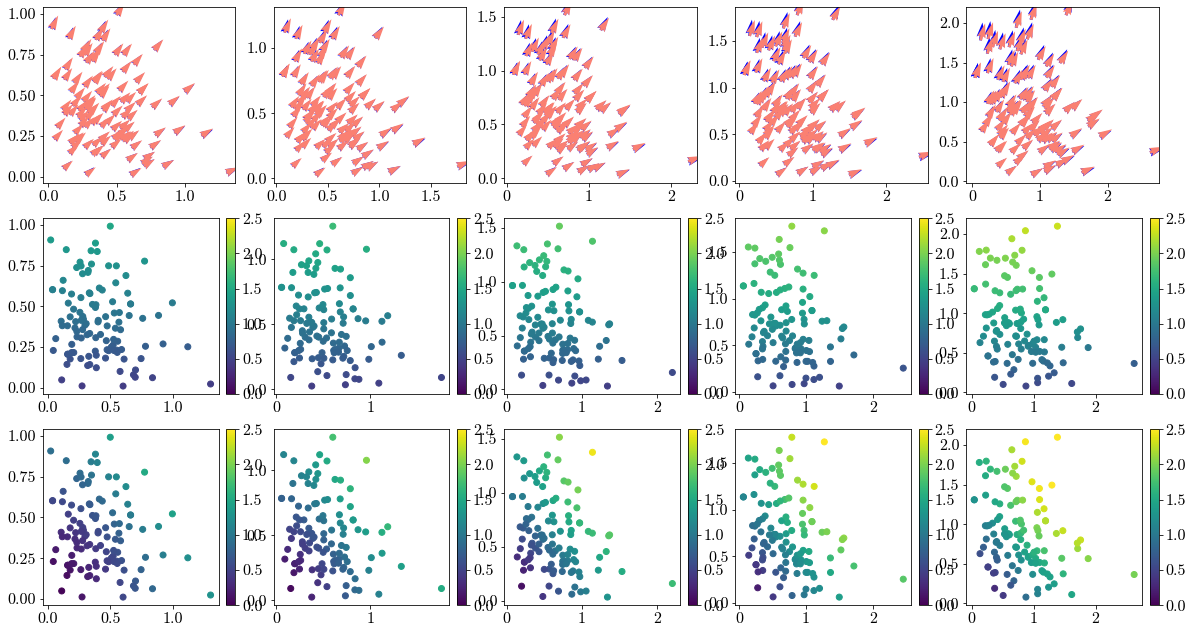

In [75]:
def drift_analytical(x,model_params_):

    a1,a2,b1,b2,K1,K2,n = model_params_
    
    force = np.zeros_like(x);
    x1n = x[:,0]**n; x2n = x[:,1]**n
    force[:,0] = (a1*x1n/((K1**n) + x1n)) + (b1*(K1**n)/((K1**n) + x2n));
    force[:,1] = (a2*x2n/((K2**n) + x2n)) + (b2*(K2**n)/((K2**n) + x1n));
    return force
    
growth_net.eval()
growth_inf = growth_net(batch_ot_samples_uniform).squeeze(-1)  # shape: (nsnaps, B)
growth_ = gr*((batch_ot_samples_uniform[:,:,1]**2)/(1+batch_ot_samples_uniform[:,:,1]**2)  + (batch_ot_samples_uniform[:,:,0]**2)/(1+batch_ot_samples_uniform[:,:,0]**2))
log_mass = torch.zeros_like(growth_)
log_mass[0] = np.log(1. / nsamples)
for k in range(1, nsnaps):
    log_mass[k] = log_mass[k - 1] + 0.5 * dt * (growth_[k] + growth_[k - 1])
mass_ = torch.exp(log_mass)

res = 4;
total_err = 0;
samples = batch_ot_samples_uniform.cpu().data.numpy() + 0; #np.asarray(samples_full)
for k in range(0,tp.shape[0]):
    xtest = torch.tensor(samples[k,:,0:Ndim], dtype=torch.float32, device=device)
    force  = drift_analytical(xtest.cpu().data.numpy(),model_params) 
    drift  = drift_net(xtest).cpu().data.numpy()

    print(" RMSE ", np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )  )
    total_err = total_err + np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )
    
    plt.subplot(3,tp.shape[0],k+1)
    plt.quiver(samples[k,::res,0], samples[k,::res,1], force[::res,0], force[::res,1],scale=25,width=0.015,alpha=1.0,color='blue')
    plt.quiver(samples[k,::res,0], samples[k,::res,1], drift[::res,0], drift[::res,1],scale=25,width=0.015,alpha=1.0,color='salmon')

    plt.subplot(3,tp.shape[0],tp.shape[0]+k+1)
    plt.scatter(samples[k,::res,0], samples[k,::res,1], c = growth_inf[k,::res].cpu().data.numpy(),vmin=0,vmax=2.5)
    plt.colorbar(pad=0.04, fraction=0.046)

    plt.subplot(3,tp.shape[0],2*tp.shape[0]+k+1)
    plt.scatter(samples[k,::res,0], samples[k,::res,1], c = growth_[k,::res].cpu().data.numpy(),vmin=0,vmax=2.5)
    plt.colorbar(pad=0.04, fraction=0.046)
    #plt.quiver(samples[k,::res,0], samples[k,::res,1], drift[::res,0], drift[::res,1],scale=25,width=0.015,alpha=1.0,color='salmon')
print(" total err ", total_err/tp.shape[0])
plt.gcf().set_size_inches(20,11)

torch.Size([10, 455]) torch.Size([10, 455])
 rmse of growth  tensor(0.0981, device='cuda:0', grad_fn=<DivBackward0>)


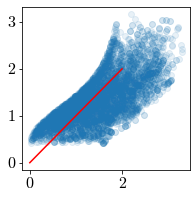

In [77]:
print(growth_.shape, growth_inf.shape)

plt.scatter(growth_.flatten().cpu().data.numpy(), growth_inf.flatten().cpu().data.numpy(),alpha=0.1)
plt.plot(np.linspace(0,2,10), np.linspace(0,2,10),color='red')
plt.gcf().set_size_inches(3,3)

rmse_growth = torch.mean((growth_ - growth_inf).flatten()**2)/torch.mean(growth_.flatten()**2)
print(" rmse of growth ", rmse_growth)